In [3]:
import random

def lotto_generator():
    # Generate 6 unique numbers from 1 to 45
    numbers = random.sample(range(1, 46), 6)
    return sorted(numbers)

# Generate and print lotto numbers
print("로또 번호:", lotto_generator())

로또 번호: [1, 17, 25, 29, 40, 41]


In [4]:
import random

def monte_carlo_lotto_generator(num_simulations=1000):
    # 각 번호의 빈도를 저장할 딕셔너리
    frequency = {i: 0 for i in range(1, 46)}
    
    # 몬테카를로 시뮬레이션: 여러 번 번호 생성하여 빈도 계산
    for _ in range(num_simulations):
        numbers = random.sample(range(1, 46), 6)
        for num in numbers:
            frequency[num] += 1
    
    # 가장 빈번한 번호 6개를 선택하여 정렬
    sorted_numbers = sorted(frequency.items(), key=lambda x: x[1], reverse=True)
    selected_numbers = [num for num, _ in sorted_numbers[:6]]
    return sorted(selected_numbers)

# 몬테카를로 시뮬레이션으로 로또 번호 생성 및 출력
print("몬테카를로 로또 번호:", monte_carlo_lotto_generator())

몬테카를로 로또 번호: [4, 12, 17, 35, 36, 44]


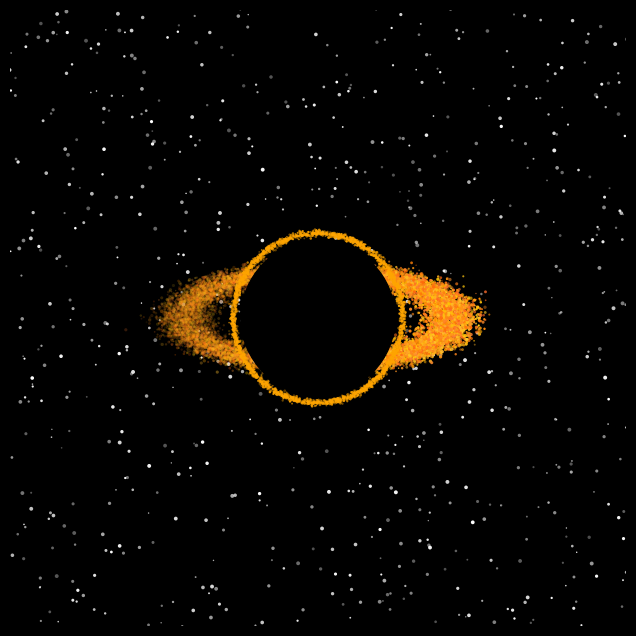

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 재현 가능한 난수
np.random.seed(42)

fig, ax = plt.subplots(figsize=(8, 8), facecolor="black")
ax.set_facecolor("black")

# 1. 배경 별 생성
n_stars = 1200
star_x = np.random.uniform(-10, 10, n_stars)
star_y = np.random.uniform(-10, 10, n_stars)
star_size = np.random.uniform(1, 8, n_stars)
star_alpha = np.random.uniform(0.3, 1.0, n_stars)

ax.scatter(star_x, star_y, s=star_size, c="white", alpha=star_alpha, linewidths=0)

# 2. 강착원반(밝은 고리) 생성
n_disk = 15000
theta = np.random.uniform(0, 2*np.pi, n_disk)

# 반지름을 고리 형태로 만들기 위해 정규분포 사용
r = np.random.normal(loc=3.5, scale=0.35, size=n_disk)

# 약간 찌그러진 원반처럼 보이게 y축 압축
x_disk = r * np.cos(theta)
y_disk = 0.35 * r * np.sin(theta)

# 난수로 밝기 변화
brightness = np.clip(np.random.normal(0.8, 0.25, n_disk), 0.1, 1.0)

# 앞쪽이 더 밝아 보이도록 단순 가중치
front_boost = (np.cos(theta) + 1.5) / 2.5
alpha_disk = np.clip(brightness * front_boost, 0.05, 1.0)

ax.scatter(
    x_disk, y_disk,
    s=np.random.uniform(1, 6, n_disk),
    c=np.column_stack([
        np.ones(n_disk),
        np.random.uniform(0.4, 0.8, n_disk),
        np.random.uniform(0.0, 0.2, n_disk)
    ]),
    alpha=alpha_disk,
    linewidths=0
)

# 3. 중심 사건지평선(검은 원)
event_horizon = plt.Circle((0, 0), 2.0, color="black", zorder=10)
ax.add_patch(event_horizon)

# 4. 광자 고리 느낌의 얇은 밝은 테두리
n_ring = 3000
theta_ring = np.random.uniform(0, 2*np.pi, n_ring)
r_ring = np.random.normal(loc=2.2, scale=0.04, size=n_ring)

x_ring = r_ring * np.cos(theta_ring)
y_ring = r_ring * np.sin(theta_ring)

ax.scatter(
    x_ring, y_ring,
    s=np.random.uniform(1, 4, n_ring),
    c="orange",
    alpha=np.random.uniform(0.3, 0.9, n_ring),
    linewidths=0,
    zorder=11
)

# 5. 보기 설정
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_aspect("equal")
ax.axis("off")

plt.show()